In [44]:
from numpy import  meshgrid, append, max, min, array, sin, pi, zeros_like
from pandas import read_excel
from phc_codes.spectra_utils import clip_wl
import matplotlib.pyplot as plt
%matplotlib widget

## Load and pick excel multicolum data

In [45]:
data = read_excel(
    r"data/PhC_dispersion_TE.xlsx",
    header=None,
)
measured_angles = array([float(angle[:2]) for angle in data.iloc[0, 1:]])
angles = measured_angles # for hemicylindrical prism
spectrum_data = data.iloc[6:, :].to_numpy(float)
# print(data.head(7))

## plot the dispersion data

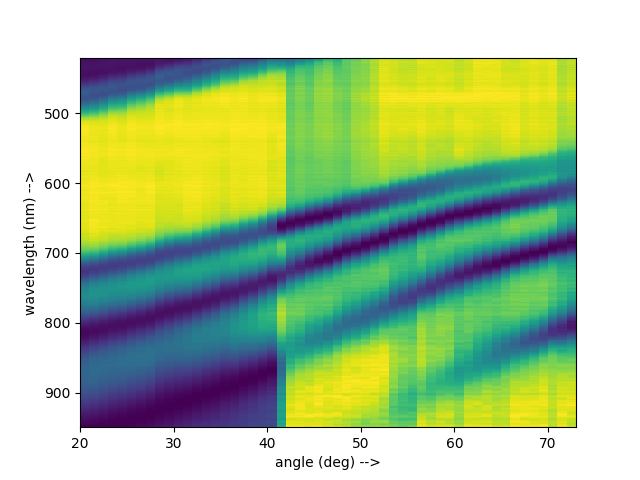

In [46]:
# wavelength range to plot
wl1 = 420
wl2 = 950

spectrum_data = clip_wl(spectrum_data, wl1, wl2)
wavelengths = spectrum_data[:, 0]
reflectance = spectrum_data[:, 1:]
offset_reflectance =  reflectance  - min(reflectance, axis=0)
normalized_reflectance = offset_reflectance / max(offset_reflectance, axis=0)

X, Y = meshgrid(append(angles, angles[-1]), append(wavelengths, wavelengths[-1]))
#plot_data = log10(normalized_reflectance+100)
plot_data = normalized_reflectance
plt.figure(1)
fig, ax = plt.subplots()
cplot = ax.pcolormesh(
    X, Y, plot_data, shading="flat", antialiased=True
)  # x_tick = row index, y_tick = column index
#fig.colorbar(cplot, label="log$_{10}$(count)")
plt.xlabel("angle (deg) -->")
plt.ylabel("wavelength (nm) -->")
ax.invert_yaxis()
# plt.plot(data[:,0], data[:,3])
plt.show()

## Represent in  $\omega$ - k  

In [47]:
a = 96 + 55 # lattice parameter 
def lmda_theta_to_omega_k(lmda, theta):
    """convert lambda-theta data to omega/c-k_x data for phc
    lmda : float , in units of nm
    theta : float , in units of degree"""
    n_sub = 1.5
    omega = a / lmda
    k_x = n_sub* omega * sin(theta * pi / 180)
    return omega, k_x

y_size, x_size = plot_data.shape
Omega = zeros_like(Y)
Kx = zeros_like(X)
for i in range(y_size+1):
    for j in range(x_size+1):
        Omega[i,j], Kx[i,j] = lmda_theta_to_omega_k(Y[i,j], X[i,j])


## plot

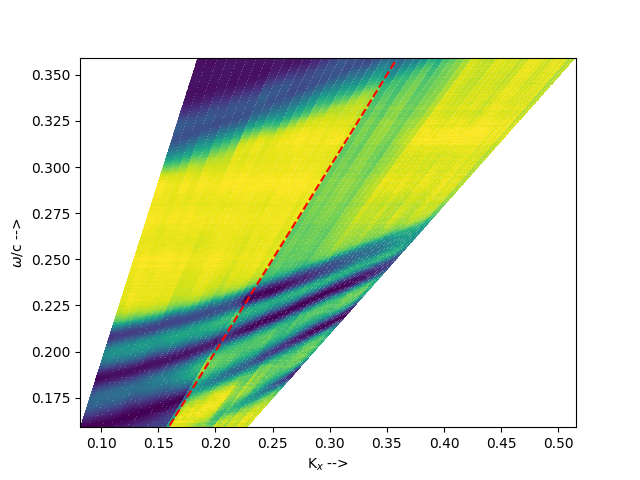

In [51]:

plt.figure(2)
fig, ax = plt.subplots()
cplot = ax.pcolormesh(
    Kx, Omega, plot_data, shading="flat", antialiased=True
)  # x_tick = row index, y_tick = column index
#fig.colorbar(cplot, label="log$_{10}$(count)")
ax.plot([0.16, 0.357], [0.16, 0.357], '--r')
plt.xlabel("K$_x$ -->")
plt.ylabel(r"$\omega$/c -->")
plt.show()

In [49]:

def theta_to_n(theta):
    """convert lambda-theta data to lmda-n data for phc
    lmda : float , in units of nm
    theta : float , in units of degree"""
    n_sub = 1.5
    n_eff = n_sub *  sin(theta * pi / 180)
    return n_eff

y_size, x_size = plot_data.shape
nn = zeros_like(X)
for i in range(y_size+1):
    for j in range(x_size+1):
        nn[i,j] = theta_to_n(X[i,j])

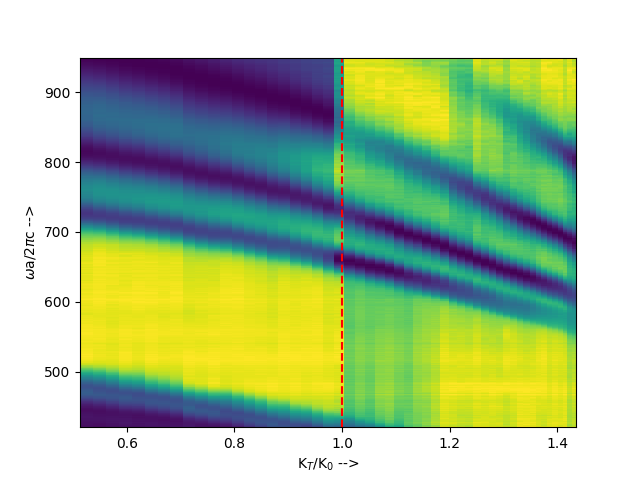

In [50]:
plt.figure(5)
plt.clf()
fig, ax = plt.subplots()
cplot = ax.pcolormesh(
    nn, Y, plot_data, antialiased=True
)  # x_tick = row index, y_tick = column index
#fig.colorbar(cplot, label="log$_{10}$(count)")
ax.plot([1, 1], [421, 949], "--r")
plt.xlabel(r"K$_T$/K$_0$ -->")
plt.ylabel(r"$\omega$a/2$\pi$c -->")
plt.show()